In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from io import StringIO

# Setting random seed for reproducibility
np.random.seed(42)

# Setting matplotlib style
plt.style.use('seaborn-v0_8')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


# 1️⃣ Load data
data = pd.read_csv('/kaggle/input/cryptocurrency/ethereum_historical_yahoo.csv')
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values('date')

/kaggle/input/cryptocurrency/bitcoin_historical_yahoo.csv
/kaggle/input/cryptocurrency/solana_historical_yahoo.csv
/kaggle/input/cryptocurrency/ethereum_historical_yahoo.csv


In [16]:
print("=== BITCOIN PRICE PREDICTION - RANDOM FOREST ===")
print(f"Dataset: {len(data)} samples from {data['date'].min().strftime('%Y-%m-%d')} to {data['date'].max().strftime('%Y-%m-%d')}")
print()

# Selecting features - similar to your LSTM approach
features = data[['open', 'high', 'low', 'close', 'volume']]
target = data['close']

# Splitting data into train/test (80%/20%)
train_size = int(len(features) * 0.8)
X_train, X_test = features[:train_size], features[train_size:]
y_train, y_test = target[:train_size], target[train_size:]

print(f"Training data: {len(X_train)} samples")
print(f"Test data: {len(X_test)} samples")
print()

=== BITCOIN PRICE PREDICTION - RANDOM FOREST ===
Dataset: 2732 samples from 2017-11-09 to 2025-05-02

Training data: 2185 samples
Test data: 547 samples



In [17]:
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

# Random Forest Model
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest model...")
model.fit(X_train_scaled, y_train_scaled)


Training Random Forest model...


RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

In [18]:
# Make predictions
train_pred_scaled = model.predict(X_train_scaled)
test_pred_scaled = model.predict(X_test_scaled)

# Inverse transform predictions
train_pred = scaler_y.inverse_transform(train_pred_scaled.reshape(-1, 1)).flatten()
test_pred = scaler_y.inverse_transform(test_pred_scaled.reshape(-1, 1)).flatten()

# Evaluation metrics
def print_metrics(actual, predicted, set_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2 = r2_score(y_test, test_pred)
    
    
    print(f"{set_name} Set Metrics:")
    print(f"MAE: ${mae:.2f}")
    print(f"RMSE: ${rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R²  : {r2:.6f}")
    print(f"Last Actual: ${actual.iloc[-1]:.2f}")
    print(f"Last Predicted: ${predicted[-1]:.2f}")
    print()

print_metrics(y_train, train_pred, "Training")
print_metrics(y_test, test_pred, "Test")

Training Set Metrics:
MAE: $0.75
RMSE: $1.79
MAPE: 0.08%
R²  : 0.999932
Last Actual: $1800.62
Last Predicted: $1800.48

Test Set Metrics:
MAE: $3.68
RMSE: $5.17
MAPE: 0.13%
R²  : 0.999932
Last Actual: $1840.22
Last Predicted: $1839.85



In [19]:
# Feature importance
feature_names = ['open', 'high', 'low', 'close', 'volume']
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance:")
for _, row in importance_df.iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")
print()

Feature Importance:
close: 0.9567
low: 0.0429
high: 0.0004
open: 0.0000
volume: 0.0000



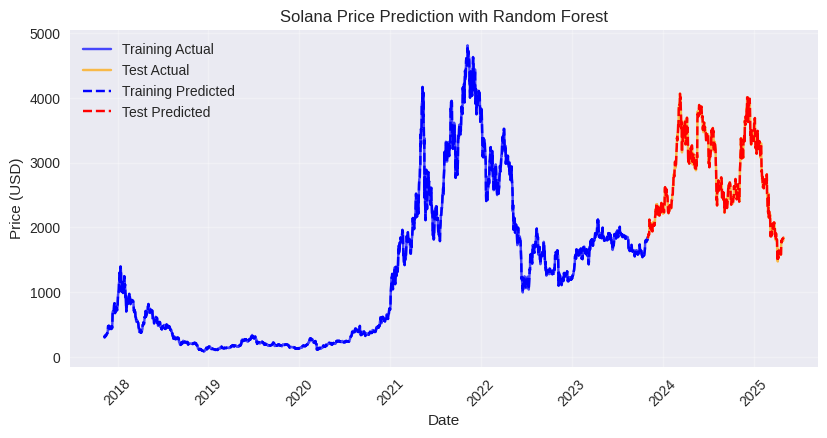

=== NEXT PERIOD PREDICTION ===
Current Price: $1840.22
Predicted Next Price: $1839.85
Expected Change: $-0.37 (-0.0%)

=== MODEL SUMMARY ===
Algorithm: Random Forest
Features: 5
Trees: 100
Training samples: 2185
Test RMSE: $5.17
Test MAPE: 0.13%


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [20]:
# Plotting results
plt.figure(figsize=(16, 8))

# Plot 1: Actual vs Predicted
#plt.subplot(2, 2, 1)
#plt.scatter(y_test, test_pred, alpha=0.7, color='blue')
#plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
#plt.xlabel('Actual Price ($)')
#plt.ylabel('Predicted Price ($)')
#plt.title('Actual vs Predicted Prices (Test Set)')
#plt.grid(True, alpha=0.3)

# Plot 2: Time series
plt.subplot(2, 2, 2)
train_dates = data['date'][:train_size]
test_dates = data['date'][train_size:]

plt.plot(train_dates, y_train, label='Training Actual', color='blue', alpha=0.7)
plt.plot(test_dates, y_test, label='Test Actual', color='orange', alpha=0.7)
plt.plot(train_dates, train_pred, label='Training Predicted', color='blue', linestyle='--')
plt.plot(test_dates, test_pred, label='Test Predicted', color='red', linestyle='--')

plt.title('Solana Price Prediction with Random Forest')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)



# Plot 3: Feature importance
#plt.subplot(2, 2, 3)
#plt.barh(importance_df['feature'], importance_df['importance'], color='skyblue')
#plt.xlabel('Importance')
#plt.title('Feature Importance')
#plt.grid(True, alpha=0.3)

# Plot 4: Residuals
#plt.subplot(2, 2, 4)
#residuals = y_test - test_pred
#plt.scatter(test_pred, residuals, alpha=0.7, color='red')
#plt.axhline(y=0, color='black', linestyle='--')
#plt.xlabel('Predicted Price ($)')
#plt.ylabel('Residuals ($)')
#plt.title('Residuals Plot (Test Set)')
#plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Prediction for next period (example)
print("=== NEXT PERIOD PREDICTION ===")
last_features = features.iloc[-1:].values
last_features_scaled = scaler_X.transform(last_features)
next_pred_scaled = model.predict(last_features_scaled)
next_pred = scaler_y.inverse_transform(next_pred_scaled.reshape(-1, 1))[0, 0]

current_price = data['price'].iloc[-1]
change = next_pred - current_price
change_pct = (change / current_price) * 100

print(f"Current Price: ${current_price:.2f}")
print(f"Predicted Next Price: ${next_pred:.2f}")
print(f"Expected Change: ${change:.2f} ({change_pct:+.1f}%)")

print("\n=== MODEL SUMMARY ===")
print(f"Algorithm: Random Forest")
print(f"Features: {len(feature_names)}")
print(f"Trees: {model.n_estimators}")
print(f"Training samples: {len(X_train)}")
print(f"Test RMSE: ${np.sqrt(mean_squared_error(y_test, test_pred)):.2f}")
print(f"Test MAPE: {np.mean(np.abs((y_test - test_pred) / y_test)) * 100:.2f}%")

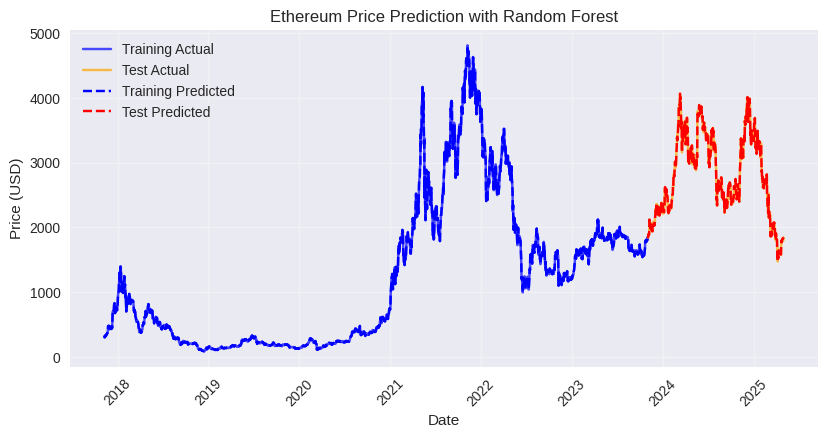

Plot salvo com sucesso em: /kaggle/working/solana_price_prediction.png


In [21]:
def salvar_plot_kaggle():
    """
    Função simples para salvar o plot no output do Kaggle
    """
    plt.figure(figsize=(16, 8))
    
    # Plot 2: Time series
    plt.subplot(2, 2, 2)
    train_dates = data['date'][:train_size]
    test_dates = data['date'][train_size:]

    plt.plot(train_dates, y_train, label='Training Actual', color='blue', alpha=0.7)
    plt.plot(test_dates, y_test, label='Test Actual', color='orange', alpha=0.7)
    plt.plot(train_dates, train_pred, label='Training Predicted', color='blue', linestyle='--')
    plt.plot(test_dates, test_pred, label='Test Predicted', color='red', linestyle='--')

    plt.title('Ethereum Price Prediction with Random Forest')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    # Ajustar layout para evitar cortes
    plt.tight_layout()
    
    # Salvar a imagem no output do Kaggle
    plt.savefig('/kaggle/working/ethereum_price_prediction.png', 
                dpi=300, 
                bbox_inches='tight')
    
    # Mostrar o plot
    plt.show()
    
    print("Plot salvo com sucesso em: /kaggle/working/solana_price_prediction.png")

# Chamar a função
salvar_plot_kaggle()